# Delivery Performance Analysis and Strategic Planning in Logistics

## Project Overview

This project analyzes logistics delivery data to evaluate delivery performance, identify factors associated with delays, calculate important logistics KPIs, and demonstrate the use of predictive analytics for logistics decision-making.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

df = pd.read_csv("../data/Delivery_Logistics.csv")

df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [9]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (25000, 15)

Columns:
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [11]:
df.isnull().sum()

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 2. Data Cleaning and Preparation

The dataset was checked for missing values and duplicate records. No missing values or duplicate rows were found. The data is therefore ready for further exploratory analysis.

In [13]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

Duplicate Rows: 0


In [14]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [15]:
df["delivery_time_hours"].head(10)

0    1970-01-01 00:00:00.000000008
1    1970-01-01 00:00:00.000000002
2    1970-01-01 00:00:00.000000010
3    1970-01-01 00:00:00.000000006
4    1970-01-01 00:00:00.000000009
5    1970-01-01 00:00:00.000000004
6    1970-01-01 00:00:00.000000006
7    1970-01-01 00:00:00.000000004
8    1970-01-01 00:00:00.000000005
9    1970-01-01 00:00:00.000000003
Name: delivery_time_hours, dtype: object

In [16]:
df["expected_time_hours"].head(10)

0    1970-01-01 00:00:00.000000008
1    1970-01-01 00:00:00.000000003
2    1970-01-01 00:00:00.000000016
3    1970-01-01 00:00:00.000000008
4    1970-01-01 00:00:00.000000016
5    1970-01-01 00:00:00.000000002
6    1970-01-01 00:00:00.000000008
7    1970-01-01 00:00:00.000000008
8    1970-01-01 00:00:00.000000008
9    1970-01-01 00:00:00.000000008
Name: expected_time_hours, dtype: object

In [17]:
df["delayed"].value_counts()


delayed
no     18331
yes     6669
Name: count, dtype: int64

In [18]:
df["delivery_status"].value_counts()

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

## 3. Exploratory Data Analysis

This section explores the main characteristics of the logistics dataset and identifies patterns related to delivery performance, delays, distance, cost, and customer ratings.

In [19]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


In [20]:
df["delivery_status"].value_counts()

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

In [21]:
df["weather_condition"].value_counts()

weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64

In [22]:
df["delayed"].value_counts()

delayed
no     18331
yes     6669
Name: count, dtype: int64

In [23]:
df["vehicle_type"].value_counts()

vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

## 4. Key Performance Indicators

The following KPIs are used to evaluate logistics delivery performance:

1. Delay Rate
2. Successful Delivery Rate
3. Average Delivery Cost
4. Average Delivery Rating

In [25]:
delay_rate = (df["delayed"].str.lower() == "yes").mean() * 100

print(f"Delay Rate: {delay_rate:.2f}%")

Delay Rate: 26.68%


In [26]:
successful_delivery_rate = (
    (df["delivery_status"].str.lower() == "delivered").mean() * 100
)

print(f"Successful Delivery Rate: {successful_delivery_rate:.2f}%")

Successful Delivery Rate: 73.32%


In [27]:
average_delivery_cost = df["delivery_cost"].mean()

print(f"Average Delivery Cost: {average_delivery_cost:.2f}")

Average Delivery Cost: 864.94


In [29]:
average_delivery_rating = df["delivery_rating"].mean()

print(f"Average Delivery Rating: {average_delivery_rating:.2f}")


Average Delivery Rating: 3.67


In [30]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Delay Rate (%)",
        "Successful Delivery Rate (%)",
        "Average Delivery Cost",
        "Average Delivery Rating"
    ],
    "Value": [
        round(delay_rate, 2),
        round(successful_delivery_rate, 2),
        round(average_delivery_cost, 2),
        round(average_delivery_rating, 2)
    ]
})

kpi_summary

,KPI,Value
0,Delay Rate (%),26.68
1,Successful Delivery Rate (%),73.32
2,Average Delivery Cost,864.94
3,Average Delivery Rating,3.67


## 5. Data Visualization

This section visualizes delivery performance and explores the relationship between different logistics factors and delivery delays.

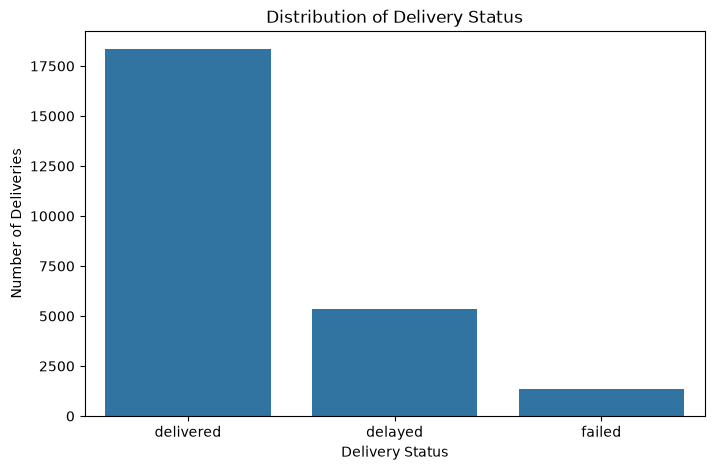

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="delivery_status"
)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

In [32]:
weather_delay = (
    df.groupby("weather_condition")["delayed"]
    .apply(lambda x: (x.str.lower() == "yes").mean() * 100)
    .reset_index()
)

weather_delay.columns = [
    "weather_condition",
    "delay_rate"
]

weather_delay = weather_delay.sort_values(
    by="delay_rate",
    ascending=False
)

weather_delay

,weather_condition,delay_rate
5,stormy,41.448309
4,rainy,37.353153
2,foggy,30.315241
0,clear,17.434530
3,hot,17.118644
1,cold,16.017316


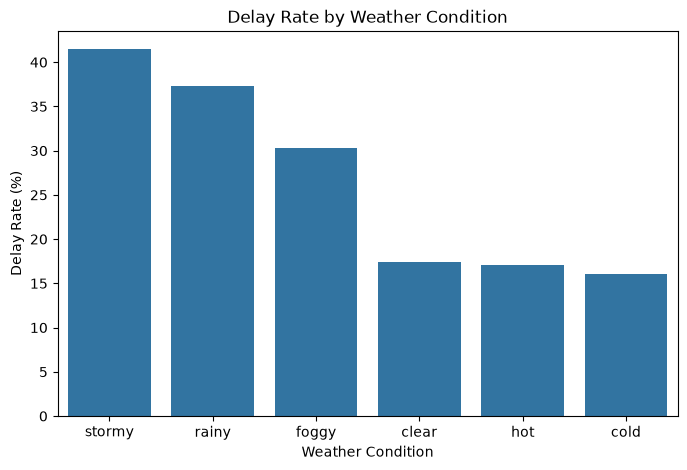

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather_delay,
    x="weather_condition",
    y="delay_rate"
)

plt.title("Delay Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Delay Rate (%)")

plt.show()

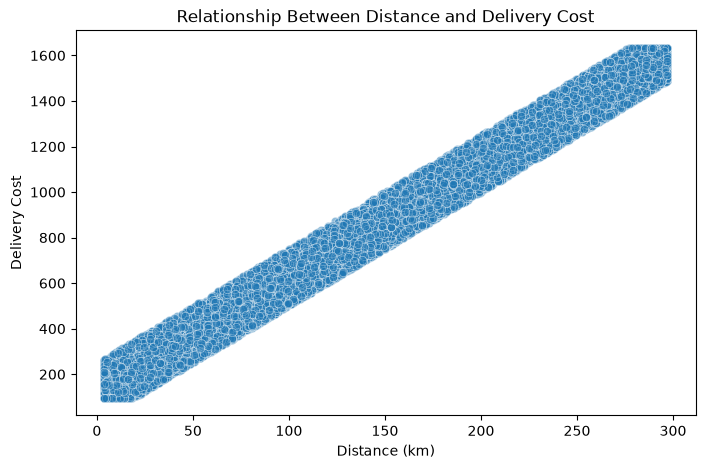

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="delivery_cost",
    alpha=0.5
)

plt.title("Relationship Between Distance and Delivery Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")

plt.show()

In [35]:
vehicle_delay = (
    df.groupby("vehicle_type")["delayed"]
    .apply(lambda x: (x.str.lower() == "yes").mean() * 100)
    .reset_index()
)

vehicle_delay.columns = [
    "vehicle_type",
    "delay_rate"
]

vehicle_delay = vehicle_delay.sort_values(
    by="delay_rate",
    ascending=False
)

vehicle_delay

,vehicle_type,delay_rate
4,truck,27.044632
0,bike,27.043269
5,van,26.773346
2,ev van,26.627794
1,ev bike,26.434329
3,scooter,26.137997


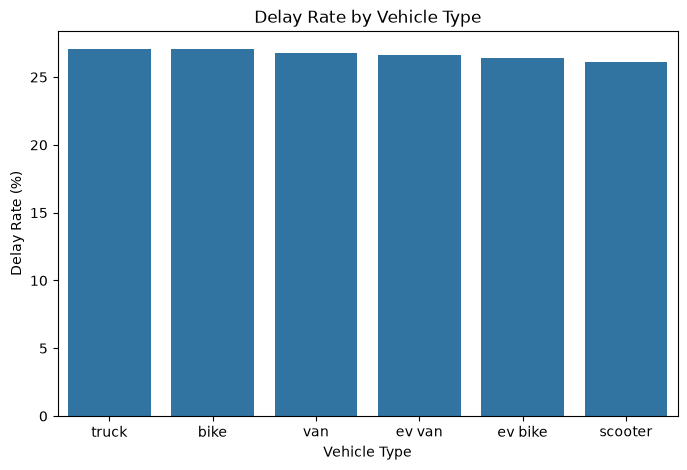

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=vehicle_delay,
    x="vehicle_type",
    y="delay_rate"
)

plt.title("Delay Rate by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Delay Rate (%)")

plt.show()

### Insight: Impact of Weather on Delivery Delays

Weather conditions have a significant impact on delivery delays. Stormy weather had the highest delay rate at approximately 41.45%, followed by rainy weather at 37.35% and foggy weather at 30.32%. In comparison, clear, hot, and cold weather conditions had delay rates below 18%.

This indicates that adverse weather conditions are strongly associated with a higher risk of delivery delays. Logistics companies can use this information to improve contingency planning and resource allocation during unfavorable weather conditions.

### Insight: Impact of Vehicle Type on Delivery Delays

The delay rates across different vehicle types are relatively similar, ranging from approximately 26.14% to 27.04%. Trucks and bikes showed the highest delay rates, while scooters had the lowest.

However, the differences between vehicle types are small. This suggests that vehicle type alone may not be a major factor contributing to delivery delays. Other factors, particularly weather conditions, may have a stronger influence on delivery performance.

In [37]:
correlation = df["distance_km"].corr(df["delivery_cost"])

print(f"Correlation between Distance and Delivery Cost: {correlation:.2f}")

Correlation between Distance and Delivery Cost: 0.99


### Insight: Relationship Between Distance and Delivery Cost

The correlation between distance and delivery cost is approximately 0.99, indicating a very strong positive relationship. This means that as the delivery distance increases, the delivery cost also tends to increase.

This finding suggests that distance is an important factor in logistics cost management. The company can use distance-based analysis to improve route planning, control delivery costs, and allocate resources more efficiently.

## 6. Predictive Modeling

A Logistic Regression model is used to predict whether a delivery is likely to be delayed. The model uses logistics-related features such as delivery partner, package type, vehicle type, delivery mode, region, weather conditions, distance, package weight, expected delivery time, and delivery cost.

In [39]:
df["delay_target"] = (
    df["delayed"].str.lower() == "yes"
).astype(int)

df["delay_target"].value_counts()

delay_target
0    18331
1     6669
Name: count, dtype: int64

In [40]:
features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg",
    "expected_time_hours",
    "delivery_cost"
]

X = df[features]
y = df["delay_target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (25000, 10)
Target shape: (25000,)


In [41]:
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'expected_time_hours']

Numerical Features:
['distance_km', 'package_weight_kg', 'delivery_cost']


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [44]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (20000, 10)
Testing data shape: (5000, 10)


In [46]:
model.fit(X_train, y_train)

C:\Users\BHAVANA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['delivery_partner','package_type','vehicle_type',...,'package_weight_kg', 'expected_time_hours','delivery_cost']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'

In [47]:
predictions = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 89.56%


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3666
           1       0.80      0.82      0.81      1334

    accuracy                           0.90      5000
   macro avg       0.86      0.87      0.87      5000
weighted avg       0.90      0.90      0.90      5000



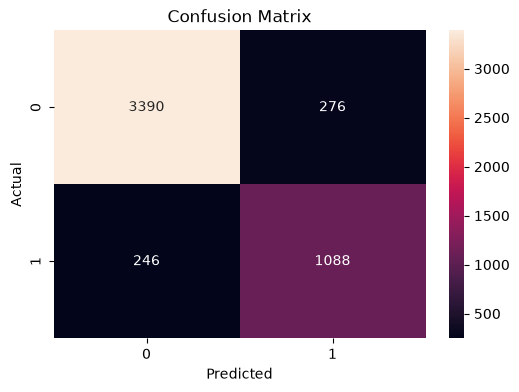

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model Performance

A Logistic Regression model was developed to predict whether a delivery would be delayed. The dataset was divided into 80% training data and 20% testing data. Categorical variables were converted into numerical representations using One-Hot Encoding.

The model achieved an accuracy of 89.56% on the test dataset. This indicates that the model correctly classified approximately 90 out of every 100 delivery records.

## 7. Key Findings

The analysis of the logistics delivery dataset produced the following findings:

1. The overall delay rate was 26.68%, indicating that more than one-fourth of the deliveries experienced delays.

2. The successful delivery rate was 73.32%, showing that most deliveries were completed successfully.

3. The average delivery cost was 864.94, which provides a useful baseline for monitoring logistics expenses.

4. The average customer rating was 3.67 out of 5, indicating a moderate level of customer satisfaction.

5. Weather conditions showed a clear relationship with delivery delays. Stormy weather had the highest delay rate at approximately 41.45%, followed by rainy weather at 37.35% and foggy weather at 30.32%.

6. Clear, hot, and cold weather conditions had considerably lower delay rates, all below 18%.

7. Delivery distance had a very strong positive correlation with delivery cost, with a correlation coefficient of 0.99. This indicates that longer delivery distances are strongly associated with higher delivery costs.

8. Delay rates across vehicle types were relatively similar, ranging from approximately 26.14% to 27.04%. Therefore, vehicle type alone does not appear to be a major factor affecting delivery delays.

9. The Logistic Regression model achieved an accuracy of 89.56% in predicting whether a delivery would be delayed.

## 8. Strategic Recommendations

Based on the analysis, the following recommendations can be made:

1. **Weather-based planning:** Logistics companies should prepare contingency plans for stormy, rainy, and foggy conditions because these conditions are associated with higher delay rates.

2. **Predictive delay monitoring:** The Logistic Regression model can be used as a supporting tool to identify deliveries that have a higher probability of being delayed.

3. **Distance-based cost management:** Since distance has a very strong relationship with delivery cost, route planning and delivery scheduling should consider distance carefully to control operational expenses.

4. **Resource allocation:** Delivery resources such as vehicles and delivery personnel can be allocated based on factors such as distance, weather, and delivery requirements.

5. **Continuous KPI monitoring:** Delay rate, successful delivery rate, average delivery cost, and customer rating should be monitored regularly to evaluate logistics performance.

6. **Further analysis:** Future work can include route optimization, customer segmentation, advanced classification models, and real-time weather and traffic information.

## 9. Conclusion

This project demonstrates how data analysis and machine learning can support strategic decision-making in logistics. A logistics delivery dataset containing 25,000 records and 15 features was analyzed to understand delivery performance and identify factors associated with delays.

The analysis showed an overall delay rate of 26.68% and a successful delivery rate of 73.32%. Weather conditions were found to have an important relationship with delivery delays, with stormy and rainy conditions showing considerably higher delay rates. Distance also showed a very strong positive relationship with delivery cost, with a correlation of 0.99.

A Logistic Regression model was developed to predict delivery delays using operational and delivery-related features. The model achieved an accuracy of 89.56%, demonstrating that machine learning can be used as a supporting tool for predicting potential delivery delays.

Overall, the project shows that logistics organizations can use data-driven approaches to monitor performance, identify risks, improve resource allocation, control delivery costs, and support better operational decisions.


## 10. Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- Visual Studio Code